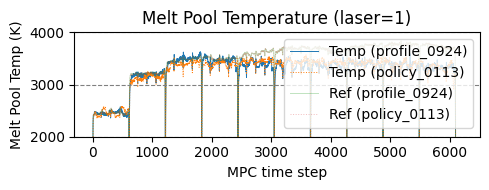

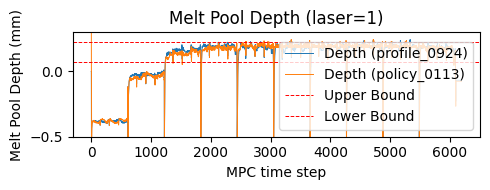

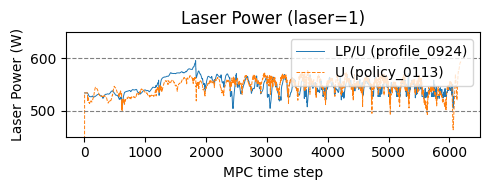

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["lines.linewidth"] = 0.7

# -----------------------------
# Readers
# -----------------------------
def read_single_csv_format(csv_path):
    """
    A 타입: 하나의 CSV에 (gamma_result_temp, gamma_result_depth, ref, LP, ...)
    반환: dict(x: (N,2), u:(N,), ref:(N,))
    """
    df = pd.read_csv(csv_path)

    norm_map = {c.strip(): c for c in df.columns}

    def pick(*names):
        for n in names:
            if n in norm_map:
                return norm_map[n]
        raise KeyError(
            f"Missing columns. Tried: {names}\nAvailable: {list(df.columns)}"
        )

    c_temp = pick("gamma_result_temp", "/gamma_result_temp", "GAMMA_RESULT_TEMP")
    c_depth = pick("gamma_result_depth", "/gamma_result_depth", "GAMMA_RESULT_DEPTH")
    c_ref = pick("ref", "REF", "Ref", "REF_LASER", "ref_laser", "Reference", "reference")
    c_u = pick("LP", "lp", "U", "u", "U_OUTPUTS_LASER", "laser_power", "LaserPower")

    x = df[[c_temp, c_depth]].to_numpy(dtype=float)
    ref = df[c_ref].to_numpy(dtype=float).flatten()
    u = df[c_u].to_numpy(dtype=float).flatten()

    return {"x": x, "u": u, "ref": ref}


def read_split_csv_format(save_dir):
    """
    B 타입: x_outputs_laser_1.csv / u_outputs_laser_1.csv / ref_laser_1.csv
    반환: dict(x: (N,2), u:(N,), ref:(N,))
    """
    x_path = os.path.join(save_dir, "x_outputs_laser_1.csv")
    u_path = os.path.join(save_dir, "u_outputs_laser_1.csv")
    ref_path = os.path.join(save_dir, "ref_laser_1.csv")

    x = pd.read_csv(x_path, header=None).to_numpy(dtype=float)
    u = pd.read_csv(u_path, header=None).to_numpy(dtype=float).flatten()
    ref = pd.read_csv(ref_path, header=None).to_numpy(dtype=float).flatten()

    if x.ndim == 1:
        x = x.reshape(-1, 1)
    if x.shape[1] >= 2:
        x = x[:, :2]
    else:
        raise ValueError(f"x_outputs has only {x.shape[1]} columns; need >= 2 (temp, depth).")

    return {"x": x, "u": u, "ref": ref}


# -----------------------------
# Plot (3 figures)
# -----------------------------
def plot_compare_outputs_laser1_three_figs(
    single_csv_path,
    split_save_dir,
    N_step=None,
    labels=("SingleCSV", "SplitCSV"),
):
    """
    laser=1만 고정.
    Temp / Depth / LP를 각각 별도 figure로 띄움.
    """
    data_a = read_single_csv_format(single_csv_path)
    data_b = read_split_csv_format(split_save_dir)

    xa, ua, refa = data_a["x"], data_a["u"], data_a["ref"]
    xb, ub, refb = data_b["x"], data_b["u"], data_b["ref"]

    if N_step is None:
        N_step = min(len(xa), len(ua), len(refa), len(xb), len(ub), len(refb))

    xa, ua, refa = xa[:N_step], ua[:N_step], refa[:N_step]
    xb, ub, refb = xb[:N_step], ub[:N_step], refb[:N_step]

    la, lb = labels

    # ---- Figure 1: Temperature ----
    plt.figure(figsize=(5,2))
    plt.title("Melt Pool Temperature (laser=1)")
    plt.plot(xa[:, 0], label=f"Temp ({la})")
    plt.plot(xb[:, 0], label=f"Temp ({lb})", linestyle=":")
    plt.plot(refa, label=f"Ref ({la})", alpha=0.3)
    plt.plot(refb, label=f"Ref ({lb})", alpha=0.3, linestyle=":")
    for yline in [2000, 3000, 4000]:
        plt.axhline(y=yline, color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Temp (K)")
    plt.legend(loc="best")
    plt.tight_layout()
    #plt.xlim(0000,6100)
    plt.ylim(2000, 4000)
    plt.show()

    # ---- Figure 2: Depth ----
    plt.figure(figsize=(5,2))
    plt.title("Melt Pool Depth (laser=1)")
    plt.plot(xa[:, 1], label=f"Depth ({la})")
    plt.plot(xb[:, 1], label=f"Depth ({lb})")
    plt.axhline(y=0.225, linestyle="--", color="r", label="Upper Bound")
    plt.axhline(y=0.075, linestyle="--", color="r", label="Lower Bound")
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend(loc="best")
    plt.ylim(-0.5, 0.3)
    #plt.xlim(0000,6100)
    plt.tight_layout()
    plt.show()

    # ---- Figure 3: Laser Power ----
    plt.figure(figsize=(5,2))
    plt.title("Laser Power (laser=1)")
    plt.plot(ua, label=f"LP/U ({la})")
    plt.plot(ub, label=f"U ({lb})", linestyle="--")
    for yline in [500, 600, 700]:
        plt.axhline(y=yline, color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel("MPC time step")
    plt.ylabel("Laser Power (W)")
    plt.legend(loc="best")
    plt.ylim(450, 650)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    single_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"
    split_dir = "/home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/simulation"

    plot_compare_outputs_laser1_three_figs(
        single_csv_path=single_csv,
        split_save_dir=split_dir,
        N_step=None,
        labels=("profile_0924", "policy_0113"),
    )


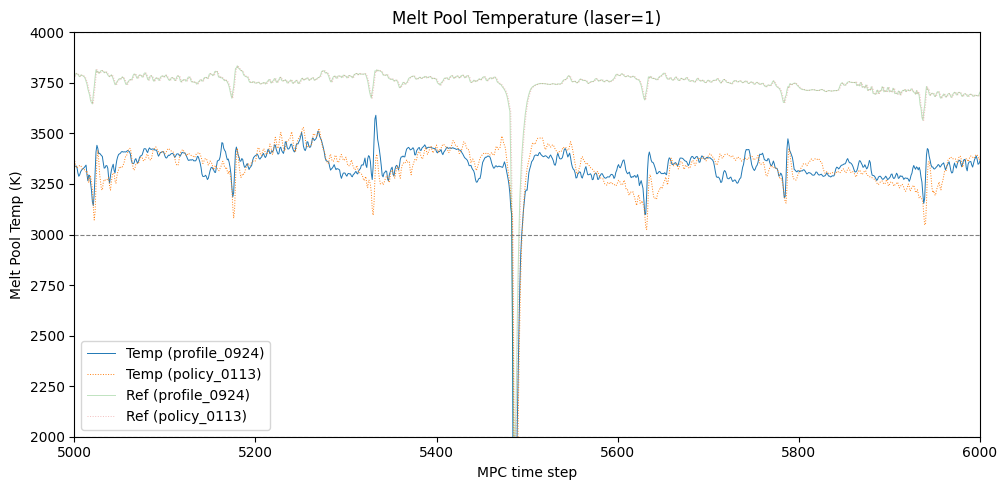

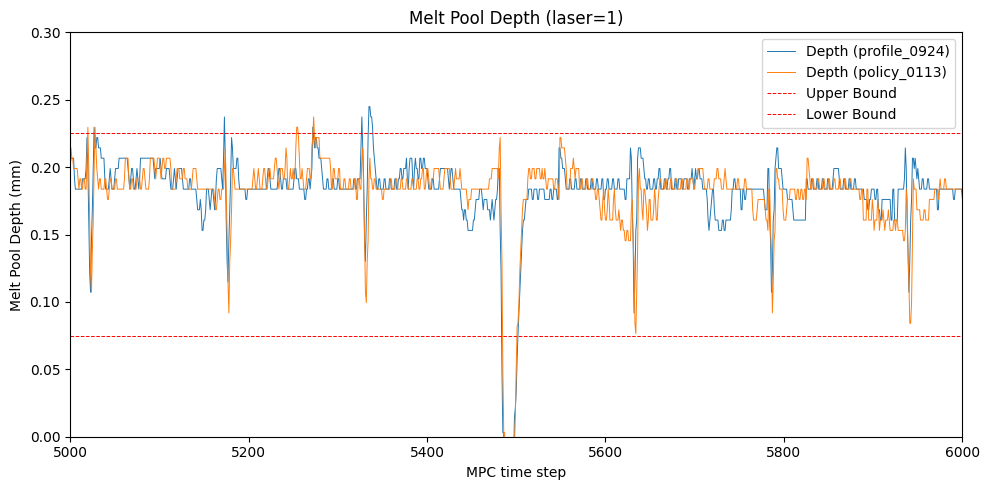

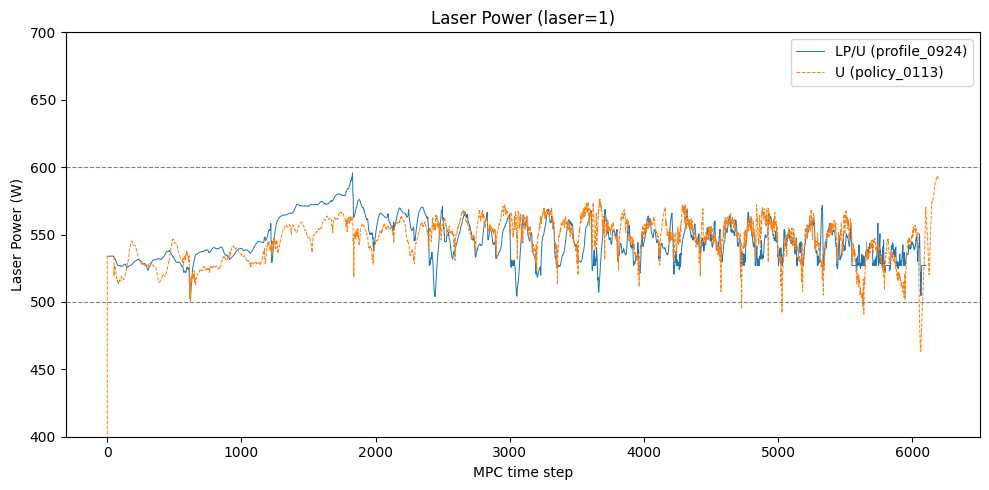

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["lines.linewidth"] = 0.7

# -----------------------------
# Readers
# -----------------------------
def read_single_csv_format(csv_path):
    """
    A 타입: 하나의 CSV에 (gamma_result_temp, gamma_result_depth, ref, LP, ...)
    반환: dict(x: (N,2), u:(N,), ref:(N,))
    """
    df = pd.read_csv(csv_path)

    norm_map = {c.strip(): c for c in df.columns}

    def pick(*names):
        for n in names:
            if n in norm_map:
                return norm_map[n]
        raise KeyError(
            f"Missing columns. Tried: {names}\nAvailable: {list(df.columns)}"
        )

    c_temp = pick("gamma_result_temp", "/gamma_result_temp", "GAMMA_RESULT_TEMP")
    c_depth = pick("gamma_result_depth", "/gamma_result_depth", "GAMMA_RESULT_DEPTH")
    c_ref = pick("ref", "REF", "Ref", "REF_LASER", "ref_laser", "Reference", "reference")
    c_u = pick("LP", "lp", "U", "u", "U_OUTPUTS_LASER", "laser_power", "LaserPower")

    x = df[[c_temp, c_depth]].to_numpy(dtype=float)
    ref = df[c_ref].to_numpy(dtype=float).flatten()
    u = df[c_u].to_numpy(dtype=float).flatten()

    return {"x": x, "u": u, "ref": ref}


def read_split_csv_format(save_dir):
    """
    B 타입: x_outputs_laser_1.csv / u_outputs_laser_1.csv / ref_laser_1.csv
    반환: dict(x: (N,2), u:(N,), ref:(N,))
    """
    x_path = os.path.join(save_dir, "x_outputs_laser_1.csv")
    u_path = os.path.join(save_dir, "u_outputs_laser_1.csv")
    ref_path = os.path.join(save_dir, "ref_laser_1.csv")

    x = pd.read_csv(x_path, header=None).to_numpy(dtype=float)
    u = pd.read_csv(u_path, header=None).to_numpy(dtype=float).flatten()
    ref = pd.read_csv(ref_path, header=None).to_numpy(dtype=float).flatten()

    if x.ndim == 1:
        x = x.reshape(-1, 1)
    if x.shape[1] >= 2:
        x = x[:, :2]
    else:
        raise ValueError(f"x_outputs has only {x.shape[1]} columns; need >= 2 (temp, depth).")

    return {"x": x, "u": u, "ref": ref}


# -----------------------------
# Plot (3 figures)
# -----------------------------
def plot_compare_outputs_laser1_three_figs(
    single_csv_path,
    split_save_dir,
    N_step=None,
    labels=("SingleCSV", "SplitCSV"),
):
    """
    laser=1만 고정.
    Temp / Depth / LP를 각각 별도 figure로 띄움.
    """
    data_a = read_single_csv_format(single_csv_path)
    data_b = read_split_csv_format(split_save_dir)

    xa, ua, refa = data_a["x"], data_a["u"], data_a["ref"]
    xb, ub, refb = data_b["x"], data_b["u"], data_b["ref"]

    if N_step is None:
        N_step = min(len(xa), len(ua), len(refa), len(xb), len(ub), len(refb))

    xa, ua, refa = xa[:N_step], ua[:N_step], refa[:N_step]
    xb, ub, refb = xb[:N_step], ub[:N_step], refb[:N_step]

    la, lb = labels

    # ---- Figure 1: Temperature ----
    plt.figure(figsize=(10, 5))
    plt.title("Melt Pool Temperature (laser=1)")
    plt.plot(xa[:, 0], label=f"Temp ({la})")
    plt.plot(xb[:, 0], label=f"Temp ({lb})", linestyle=":")
    plt.plot(refa, label=f"Ref ({la})", alpha=0.3)
    plt.plot(refb, label=f"Ref ({lb})", alpha=0.3, linestyle=":")
    for yline in [2000, 3000, 4000]:
        plt.axhline(y=yline, color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Temp (K)")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.xlim(5000,6000)
    plt.ylim(2000, 4000)
    plt.show()

    # ---- Figure 2: Depth ----
    plt.figure(figsize=(10, 5))
    plt.title("Melt Pool Depth (laser=1)")
    plt.plot(xa[:, 1], label=f"Depth ({la})")
    plt.plot(xb[:, 1], label=f"Depth ({lb})")
    plt.axhline(y=0.225, linestyle="--", color="r", label="Upper Bound")
    plt.axhline(y=0.075, linestyle="--", color="r", label="Lower Bound")
    plt.xlabel("MPC time step")
    plt.ylabel("Melt Pool Depth (mm)")
    plt.legend(loc="best")
    plt.ylim(0, 0.3)
    plt.xlim(5000,6000)
    plt.tight_layout()
    plt.show()

    # ---- Figure 3: Laser Power ----
    plt.figure(figsize=(10, 5))
    plt.title("Laser Power (laser=1)")
    plt.plot(ua, label=f"LP/U ({la})")
    plt.plot(ub, label=f"U ({lb})", linestyle="--")
    for yline in [500, 600, 700]:
        plt.axhline(y=yline, color="gray", linestyle="--", linewidth=0.8)
    plt.xlabel("MPC time step")
    plt.ylabel("Laser Power (W)")
    plt.legend(loc="best")
    plt.ylim(400, 700)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    single_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"
    split_dir = "/home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/simulation"

    plot_compare_outputs_laser1_three_figs(
        single_csv_path=single_csv,
        split_save_dir=split_dir,
        N_step=None,
        labels=("profile_0924", "policy_0113"),
    )


In [3]:
def count_depth_over_threshold(single_csv_path, split_save_dir, threshold=0.225, N_step=None):
    data_a = read_single_csv_format(single_csv_path)
    data_b = read_split_csv_format(split_save_dir)

    xa = data_a["x"]  # (temp, depth)
    xb = data_b["x"]

    # 공통 길이로 맞춰서 비교
    if N_step is None:
        N_step = min(len(xa), len(xb))

    da = xa[:N_step, 1]  # depth
    db = xb[:N_step, 1]

    count_a = int(np.sum(da > threshold))
    count_b = int(np.sum(db > threshold))

    ratio_a = count_a / len(da) if len(da) > 0 else np.nan
    ratio_b = count_b / len(db) if len(db) > 0 else np.nan

    print(f"[SingleCSV] depth > {threshold}: {count_a} / {len(da)}  (ratio={ratio_a:.4f})")
    print(f"[SplitCSV ] depth > {threshold}: {count_b} / {len(db)}  (ratio={ratio_b:.4f})")

    return {
        "threshold": threshold,
        "N_step": N_step,
        "single_count": count_a,
        "single_total": len(da),
        "single_ratio": ratio_a,
        "split_count": count_b,
        "split_total": len(db),
        "split_ratio": ratio_b,
    }


In [4]:
if __name__ == "__main__":
    single_csv = "/home/ftk3187/github/DPC_research/MPC_research_submodule/DED/depth_constrained_rmpc_JMD/profile_1_RMPC_w_depth_control.csv"
    split_dir = "/home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/simulation"

    stats = count_depth_over_threshold(single_csv, split_dir, threshold=0.225)


[SingleCSV] depth > 0.225: 19 / 6196  (ratio=0.0031)
[SplitCSV ] depth > 0.225: 30 / 6196  (ratio=0.0048)
